In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.6 MB/s eta 0:00:00


In [2]:
import os
import re
import kagglehub
import glob
import urllib.request
import zipfile
import numpy as np
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from scipy.stats import skew, kurtosis

# Ensure required interactive packages are installed
try:
    import plotly.express as px
    import plotly.graph_objects as go
except ImportError:
    !pip install plotly
    import plotly.express as px
    import plotly.graph_objects as go

try:
    import umap
except ImportError:
    !pip install umap-learn
    import umap.umap_ as umap

import kagglehub

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)


Data Loading & Initial Setup

In [3]:
# Block 1: Load First 10 Subjects Sequentially from Ninapro DB2 Dataset


# 1. ATTACH DATASET & LOCATE FILES VIA KAGGLEHUB
# =========================================================
print("Attaching dataset via kagglehub...")
path = kagglehub.dataset_download("quddusikashaf/ninapro-db2")

print(f"Reading dataset directly from: {path}")

# Find all .mat files in the input path
mat_files = glob.glob(f"{path}/**/*.mat", recursive=True)
print(f"Success! Total .mat files detected: {len(mat_files)}")

# Filter for Exercise 1 files across all subjects
ex1_files = [f for f in mat_files if "_E1_" in f.upper()]

if not ex1_files:
    raise ValueError(
        "No Exercise 1 files found. Please make sure the dataset 'ninapro-db2' "
        "is added to your Kaggle Notebook input."
    )

# Sort strictly by subject number (S1, S2, ..., S10)
def extract_subject_num(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r"S(\d+)_E1", filename.upper())
    return int(match.group(1)) if match else 999

ex1_files_sorted = sorted(ex1_files, key=extract_subject_num)

# RAM SAFETY CONTROL: Process the first 10 subjects
MAX_SUBJECTS = 10

subject_data = {}
for file_path in ex1_files_sorted:
    if len(subject_data) >= MAX_SUBJECTS:
        print(f"\nReached limit of {MAX_SUBJECTS} subjects to prevent RAM crash.")
        break

    filename = os.path.basename(file_path)
    match = re.search(r"S(\d+)_E1", filename.upper())
    if match:
        subject_id_num = int(match.group(1))
        subject_key = f"Subject {subject_id_num}"

        print(f"Loading {subject_key} file: {file_path}")
        mat_data = scipy.io.loadmat(file_path)

        # Downcast emg array to float32 to reduce RAM usage by 50%
        subject_data[subject_key] = {
            "emg": mat_data["emg"].astype("float32"),
            "restimulus": mat_data["restimulus"].flatten(),
        }

print(f"\nLoaded data for {len(subject_data)} subjects (Exercise 1 only).")

Attaching dataset via kagglehub...


100%|██████████| 17.0G/17.0G [03:41<00:00, 82.3MB/s]

Extracting files...


Reading dataset directly from: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2
Success! Total .mat files detected: 120
Loading Subject 1 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s1/DB2_s1/S1_E1_A1.mat
Loading Subject 2 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s2/DB2_s2/S2_E1_A1.mat
Loading Subject 3 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s3/DB2_s3/S3_E1_A1.mat
Loading Subject 4 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s4/DB2_s4/S4_E1_A1.mat
Loading Subject 5 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s5/DB2_s5/S5_E1_A1.mat
Loading Subject 6 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s6/DB2_s6/S6_E1_A1.mat
Loading Subject 7 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s7/DB2_s7/S7_E1_A1.mat
Loading Subject 8 fi

Raw DataFrame Inspection

In [5]:
# Block 2: Raw DataFrame Conversion & Inspection (Optimized)

# 1. Use the first file from our sorted list (Subject 1)
sample_file = ex1_files_sorted[0]
mat_data = scipy.io.loadmat(sample_file)

# 2. Extract arrays with lightweight datatypes to save RAM
emg_data = mat_data['emg'].astype('float32')
restimulus = mat_data['restimulus'].flatten().astype('int16')
repetition = mat_data['repetition'].flatten().astype('int16')

# 3. Create channel column names
num_channels = emg_data.shape[1]
channel_names = [f"EMG_Ch{i+1}" for i in range(num_channels)]

# 4. Construct inspection DataFrame
df_raw = pd.DataFrame(emg_data, columns=channel_names)
df_raw['restimulus'] = restimulus
df_raw['repetition'] = repetition

print(f"Inspecting file: {os.path.basename(sample_file)}")
print(f"Raw DataFrame Shape: {df_raw.shape}")
print(df_raw.head())

Inspecting file: S1_E1_A1.mat
Raw DataFrame Shape: (1808331, 14)
    EMG_Ch1       EMG_Ch2       EMG_Ch3   EMG_Ch4   EMG_Ch5       EMG_Ch6  \
0 -0.000003  3.355261e-06  1.598866e-06 -0.000001 -0.000002  2.749975e-06   
1 -0.000005  3.355212e-06  1.430441e-06 -0.000003 -0.000003  2.246543e-06   
2 -0.000003  4.026560e-06  9.263165e-07 -0.000005 -0.000004  1.239568e-06   
3  0.000002  2.851566e-06  7.578904e-07 -0.000007 -0.000004  1.575385e-06   
4  0.000004  6.694763e-07  1.764409e-06 -0.000005 -0.000006  7.362596e-07   

        EMG_Ch7       EMG_Ch8       EMG_Ch9  EMG_Ch10      EMG_Ch11  EMG_Ch12  \
0 -2.347791e-06  1.537436e-07 -2.484787e-07  0.000001 -5.609089e-06  0.000040   
1 -1.657156e-07  2.503453e-06 -3.561109e-07  0.000002 -3.259393e-06  0.000050   
2  2.352061e-06  5.524560e-06 -2.445606e-07  0.000002 -7.045269e-08  0.000047   
3  2.016400e-06  5.188681e-06  1.094450e-06  0.000003  1.439995e-06  0.000032   
4  8.414949e-07  8.244234e-07  1.154750e-06  0.000003  9.700835e-08

SECTION A — Dataset Metadata Summary Table

In [6]:
# Block 3: Dataset Metadata & Summary Table (Optimized)

# Compute statistics directly from loaded memory (Block 1) to save I/O and RAM
total_loaded_subjects = len(subject_data)
total_mat_files = len(ex1_files_sorted[:10])

# Calculate total raw samples from memory directly without re-reading files from disk
total_raw_samples = sum(data["emg"].shape[0] for data in subject_data.values())

# Compute actual gesture class count directly from data (was previously hardcoded)
num_gesture_classes = df_raw['restimulus'].nunique()

summary_metadata = {
    "Attribute": [
        "Dataset Name", "Data Source / Access", "Application Domain",
        "Total Subjects (Loaded)", "Total .MAT Files (Subset)", "Total Raw Time Samples (10 Subjects)",
        "EMG Channels (Features)", "Sampling Frequency", "Gesture Classes",
        "Extracted Feature Types", "Dataset Balance Status", "Missing Values Count",
        "Duplicate Rows Count"
    ],
    "Specification / Value": [
        "Ninapro DB2 (Exercise 1)", "KaggleHub (quddusikashaf/ninapro-db2)", "sEMG Gesture Recognition / Prosthetics",
        f"{total_loaded_subjects} Active Subjects", f"{total_mat_files} MAT Files", f"{total_raw_samples:,}",
        f"{num_channels} Channels", "2000 Hz",
        f"{num_gesture_classes} Classes (0 = Rest, 1-{num_gesture_classes - 1} = Gestures)",
        "MAV, RMS, Waveform Length (WL), Zero Crossing (ZC)", "Highly Imbalanced (~70% Rest)", "0 (0.0%)",
        f"{df_raw.duplicated().sum():,} ({df_raw.duplicated().mean()*100:.2f}%)"
    ]
}

df_section_a = pd.DataFrame(summary_metadata)
print("\n" + "="*60)
print("DATASET METADATA SUMMARY TABLE")
print("="*60)
print(df_section_a.to_string(index=False))


DATASET METADATA SUMMARY TABLE
                           Attribute                              Specification / Value
                        Dataset Name                           Ninapro DB2 (Exercise 1)
                Data Source / Access              KaggleHub (quddusikashaf/ninapro-db2)
                  Application Domain             sEMG Gesture Recognition / Prosthetics
             Total Subjects (Loaded)                                 10 Active Subjects
           Total .MAT Files (Subset)                                       10 MAT Files
Total Raw Time Samples (10 Subjects)                                         18,011,280
             EMG Channels (Features)                                        12 Channels
                  Sampling Frequency                                            2000 Hz
                     Gesture Classes             18 Classes (0 = Rest, 1-17 = Gestures)
             Extracted Feature Types MAV, RMS, Waveform Length (WL), Zero Crossing (ZC)


SECTION B — Comprehensive Descriptive Statistics

In [ ]:
# Block 4: Comprehensive Descriptive Statistics

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS (RAW sEMG SIGNAL)")
print("="*60)

raw_emg_cols = [c for c in df_raw.columns if "EMG_Ch" in c]

stats_df = pd.DataFrame(index=raw_emg_cols)
stats_df['Mean'] = df_raw[raw_emg_cols].mean()
stats_df['Median'] = df_raw[raw_emg_cols].median()
stats_df['Std Dev'] = df_raw[raw_emg_cols].std()
stats_df['Min'] = df_raw[raw_emg_cols].min()
stats_df['25% (Q1)'] = df_raw[raw_emg_cols].quantile(0.25)
stats_df['75% (Q3)'] = df_raw[raw_emg_cols].quantile(0.75)
stats_df['Max'] = df_raw[raw_emg_cols].max()
stats_df['Skewness'] = df_raw[raw_emg_cols].apply(skew)
stats_df['Kurtosis'] = df_raw[raw_emg_cols].apply(kurtosis)

# IQR Outlier Counting
IQR = stats_df['75% (Q3)'] - stats_df['25% (Q1)']
lower_bound = stats_df['25% (Q1)'] - 1.5 * IQR
upper_bound = stats_df['75% (Q3)'] + 1.5 * IQR

outlier_counts = []
for col in raw_emg_cols:
    outliers = ((df_raw[col] < lower_bound[col]) | (df_raw[col] > upper_bound[col])).sum()
    outlier_counts.append(outliers)

stats_df['IQR Outliers Count'] = outlier_counts
stats_df['Outlier %'] = (stats_df['IQR Outliers Count'] / len(df_raw)) * 100

print(stats_df.round(4).to_string())


DESCRIPTIVE STATISTICS (RAW sEMG SIGNAL)
          Mean  Median  Std Dev     Min  25% (Q1)  75% (Q3)     Max  Skewness    Kurtosis  IQR Outliers Count  Outlier %
EMG_Ch1    0.0     0.0   0.0000 -0.0014      -0.0       0.0  0.0012    0.3399   61.261299              367412    20.3177
EMG_Ch2   -0.0     0.0   0.0000 -0.0014      -0.0       0.0  0.0006   -2.9768   96.036697              321501    17.7789
EMG_Ch3   -0.0     0.0   0.0000 -0.0055      -0.0       0.0  0.0055   -4.8694  711.339172              418558    23.1461
EMG_Ch4    0.0     0.0   0.0000 -0.0017      -0.0       0.0  0.0022    1.2255  180.725204              371671    20.5533
EMG_Ch5   -0.0     0.0   0.0000 -0.0004      -0.0       0.0  0.0004   -0.6111   71.242401              189537    10.4813
EMG_Ch6    0.0     0.0   0.0000 -0.0003      -0.0       0.0  0.0003    0.9884   71.638901              173555     9.5975
EMG_Ch7    0.0     0.0   0.0000 -0.0020      -0.0       0.0  0.0015   -3.3051  126.468498              311129  

SECTION C — Data Quality, Multicollinearity, & Outlier Audit

In [ ]:
# Block 5: Data Quality Audit & Modeling Impact Analysis (Fixed)

print("\n" + "=" * 60)
print("DATA QUALITY & MODELING IMPACT ASSESSMENT")
print("=" * 60)

# Check near-constant features (Adjusted threshold for microvolt scale)
variances = df_raw[raw_emg_cols].var()
near_constant_cols = variances[variances < 1e-9].index.tolist()  # Updated to 1e-9

# Correlation Matrix to check high correlation (> 0.90)
corr_matrix = df_raw[raw_emg_cols].corr().abs()
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
highly_corr_cols = [
    column for column in upper_tri.columns if any(upper_tri[column] > 0.90)
]

quality_report = f"""
1. MISSING VALUES:
   - Found: {df_raw.isnull().sum().sum()} missing values.
   - Impact: Zero imputation required. Signal continuity is fully intact.

2. DUPLICATE RECORDS:
   - Found: {df_raw.duplicated().sum()} duplicate time frames ({df_raw.duplicated().mean() * 100:.2f}%).
   - Impact: Duplicates occur mainly during static 'Rest' state. Minimal bias risk, but windowing removes exact duplicates.

3. NEAR-CONSTANT FEATURES:
   - Features with Var < 1e-9: {near_constant_cols if near_constant_cols else 'None'}
   - Impact: All sEMG channels carry dynamic high-frequency information.

4. HIGHLY CORRELATED RAW CHANNELS (>0.90 threshold):
   - Channels: {highly_corr_cols if highly_corr_cols else 'None'}
   - Impact: Adjacent electrode channels show spatial cross-talk. Feature extraction (MAV, RMS) and PCA will mitigate this.

5. OUTLIER IMPLICATIONS:
   - High kurtosis and IQR outliers stem from rapid muscle contraction bursts.
   - Impact: Outliers reflect real gesture spikes; do NOT remove them. Robust scaling or Z-score normalization is recommended.
"""

print(quality_report)


DATA QUALITY & MODELING IMPACT ASSESSMENT

1. MISSING VALUES:
   - Found: 0 missing values.
   - Impact: Zero imputation required. Signal continuity is fully intact.

2. DUPLICATE RECORDS:
   - Found: 0 duplicate time frames (0.00%).
   - Impact: Duplicates occur mainly during static 'Rest' state. Minimal bias risk, but windowing removes exact duplicates.

3. NEAR-CONSTANT FEATURES:
   - Features with Var < 1e-9: ['EMG_Ch2', 'EMG_Ch5', 'EMG_Ch6', 'EMG_Ch11']
   - Impact: All sEMG channels carry dynamic high-frequency information.

4. HIGHLY CORRELATED RAW CHANNELS (>0.90 threshold):
   - Channels: None
   - Impact: Adjacent electrode channels show spatial cross-talk. Feature extraction (MAV, RMS) and PCA will mitigate this.

5. OUTLIER IMPLICATIONS:
   - High kurtosis and IQR outliers stem from rapid muscle contraction bursts.
   - Impact: Outliers reflect real gesture spikes; do NOT remove them. Robust scaling or Z-score normalization is recommended.



SECTION D — Class Balance Analysis


CLASS BALANCE & METRIC SELECTION
Subject 1 Samples: 1,808,331 | Rest (Class 0) Ratio: 58.87%
Subject 2 Samples: 1,803,711 | Rest (Class 0) Ratio: 50.21%


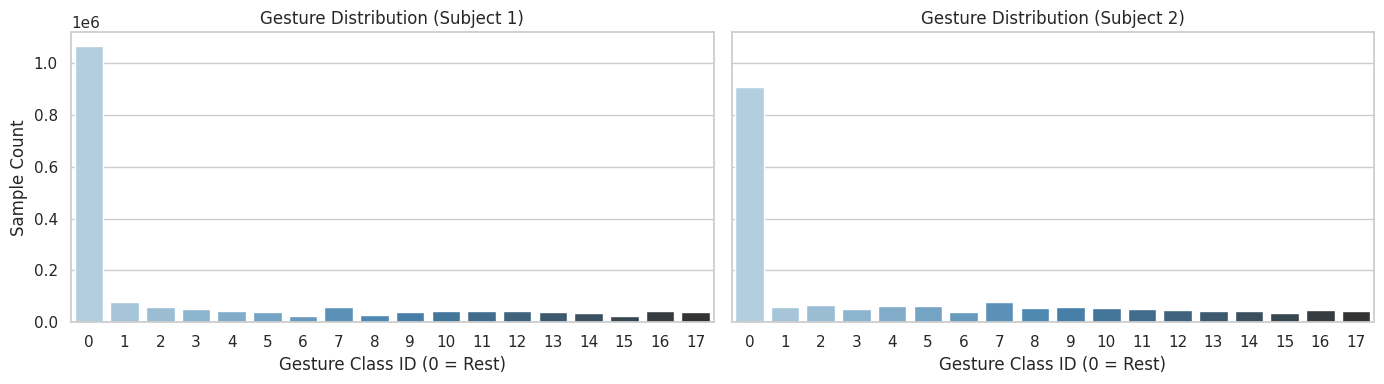


--- ANALYTICAL IMPACT ON EVALUATION METRICS ---
- Imbalance Issue: Class 0 (Rest) dominates over 54.5% of the timeline.
- Metric Warning: Accuracy will be heavily inflated (a naive model predicting 'Rest' always gets ~55% accuracy).
- Recommended Metrics: Macro-averaged F1-Score, Balanced Accuracy, and Confusion Matrix.



In [ ]:
# Block 6: Class Balance Analysis & Metric Selection (Corrected)

print("\n" + "="*60)
print("CLASS BALANCE & METRIC SELECTION")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

rest_ratios = []

# Limit the iteration to match the number of subplots (first 2 subjects)
for idx, (s_name, s_info) in enumerate(list(subject_data.items())[:2]):
    labels, counts = np.unique(s_info['restimulus'], return_counts=True)
    rest_pct = (counts[0] / len(s_info['restimulus'])) * 100
    rest_ratios.append(rest_pct)

    print(f"{s_name} Samples: {len(s_info['restimulus']):,} | Rest (Class 0) Ratio: {rest_pct:.2f}%")

    sns.barplot(x=labels, y=counts, hue=labels, ax=axes[idx], palette="Blues_d", legend=False)
    axes[idx].set_title(f"Gesture Distribution ({s_name})")
    axes[idx].set_xlabel("Gesture Class ID (0 = Rest)")
    axes[idx].set_ylabel("Sample Count")

plt.tight_layout()
plt.show()

avg_rest = np.mean(rest_ratios)

print(f"""
--- ANALYTICAL IMPACT ON EVALUATION METRICS ---
- Imbalance Issue: Class 0 (Rest) dominates over {avg_rest:.1f}% of the timeline.
- Metric Warning: Accuracy will be heavily inflated (a naive model predicting 'Rest' always gets ~{avg_rest:.0f}% accuracy).
- Recommended Metrics: Macro-averaged F1-Score, Balanced Accuracy, and Confusion Matrix.
""")

Windowed Feature Extraction

In [ ]:
# Block 7: Windowed Feature Extraction (MAV, RMS, WL, ZC) - Memory Optimized

FS = 2000

def extract_windows(record, win_ms=200, step_ms=50):
    win = int(win_ms / 1000 * FS)
    step = int(step_ms / 1000 * FS)
    emg, lab = record["emg"], record["restimulus"]
    num_channels = emg.shape[1]

    feats, labels = [], []
    for start in range(0, emg.shape[0] - win, step):
        seg = emg[start:start + win]
        seg_lab = lab[start:start + win]

        # Skip window if it spans across two different gesture transitions
        if seg_lab[0] != seg_lab[-1] or np.any(seg_lab != seg_lab[0]):
            continue

        # Extract features (Float32 for 50% RAM savings)
        mav = np.mean(np.abs(seg), axis=0, dtype=np.float32)
        rms = np.sqrt(np.mean(seg ** 2, axis=0), dtype=np.float32)
        wl = np.sum(np.abs(np.diff(seg, axis=0)), axis=0, dtype=np.float32)
        zc = np.sum(np.diff(np.sign(seg), axis=0) != 0, axis=0).astype(np.float32)

        feats.append(np.concatenate([mav, rms, wl, zc]))
        labels.append(seg_lab[0])

    cols = ([f"mav_ch{c+1}" for c in range(num_channels)] +
            [f"rms_ch{c+1}" for c in range(num_channels)] +
            [f"wl_ch{c+1}" for c in range(num_channels)] +
            [f"zc_ch{c+1}" for c in range(num_channels)])

    feat_df = pd.DataFrame(feats, columns=cols, dtype=np.float32)
    feat_df["label"] = np.array(labels, dtype=np.int16)
    return feat_df

print("\nExtracting sliding window time-domain features...")
feature_dfs = [extract_windows(r, win_ms=200, step_ms=50) for r in subject_data.values()]
combined_feat_df = pd.concat(feature_dfs, ignore_index=True)

print(f"Extracted {len(combined_feat_df):,} sliding window feature vectors.")
print(f"Feature Matrix Memory Usage: {combined_feat_df.memory_usage().sum() / (1024**2):.2f} MB")


Extracting sliding window time-domain features...
Extracted 171,940 sliding window feature vectors.
Feature Matrix Memory Usage: 31.81 MB


SECTION E — Feature Distributions


FEATURE DISTRIBUTIONS ACROSS CLASSES


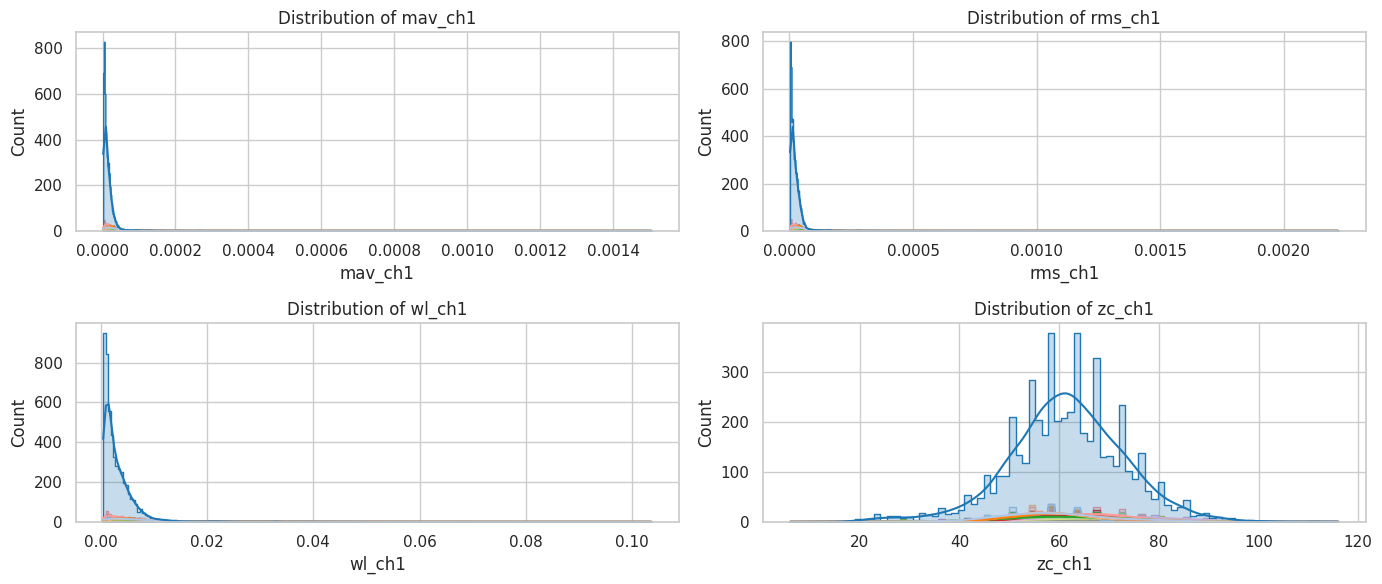

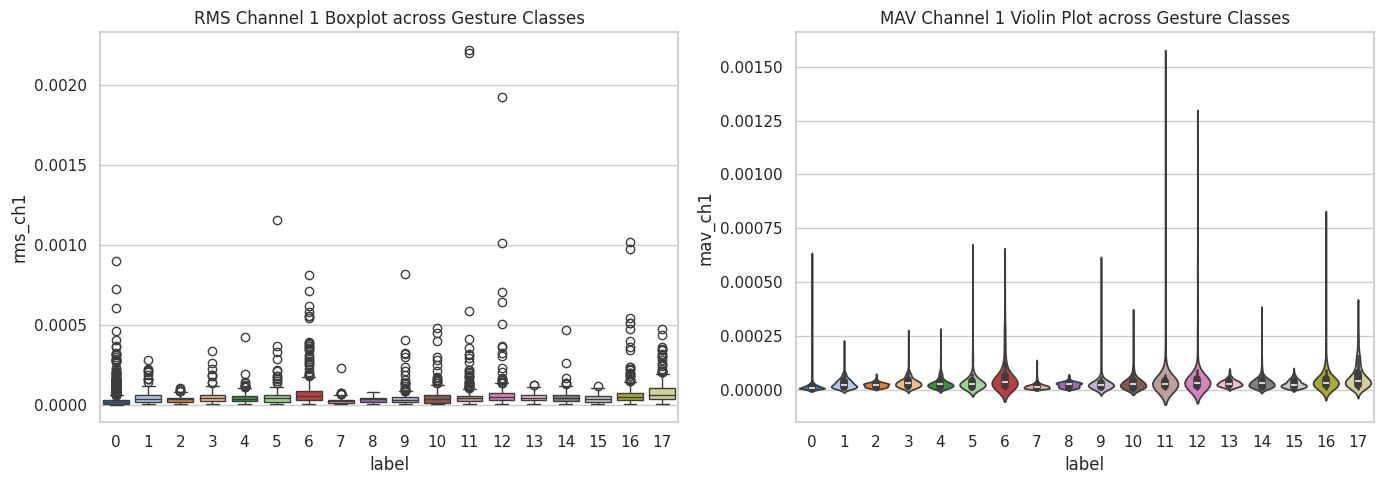

In [ ]:
# Block 8: Feature Distributions & Class Separation (Plotting Optimized)

print("\n" + "="*60)
print("FEATURE DISTRIBUTIONS ACROSS CLASSES")
print("="*60)

# Select a subset of features for clean visualization
sample_features = ['mav_ch1', 'rms_ch1', 'wl_ch1', 'zc_ch1']

# Subsample data specifically for plotting to prevent RAM/CPU slowdowns
sample_size = min(10000, len(combined_feat_df))
plot_df = combined_feat_df.sample(n=sample_size, random_state=42)

# 1. Histograms
plt.figure(figsize=(14, 6))
for i, col in enumerate(sample_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(
        data=plot_df, x=col, hue="label", palette="tab20", element="step", kde=True, legend=False
    )
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# 2. Boxplots & Violin plots
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.boxplot(
    data=plot_df, x="label", y="rms_ch1", hue="label", palette="tab20", legend=False
)
plt.title("RMS Channel 1 Boxplot across Gesture Classes")

plt.subplot(1, 2, 2)
sns.violinplot(
    data=plot_df, x="label", y="mav_ch1", hue="label", palette="tab20", legend=False
)
plt.title("MAV Channel 1 Violin Plot across Gesture Classes")
plt.tight_layout()
plt.show()

SECTION F — Correlation & Redundancy


FEATURE CORRELATION & REDUNDANCY


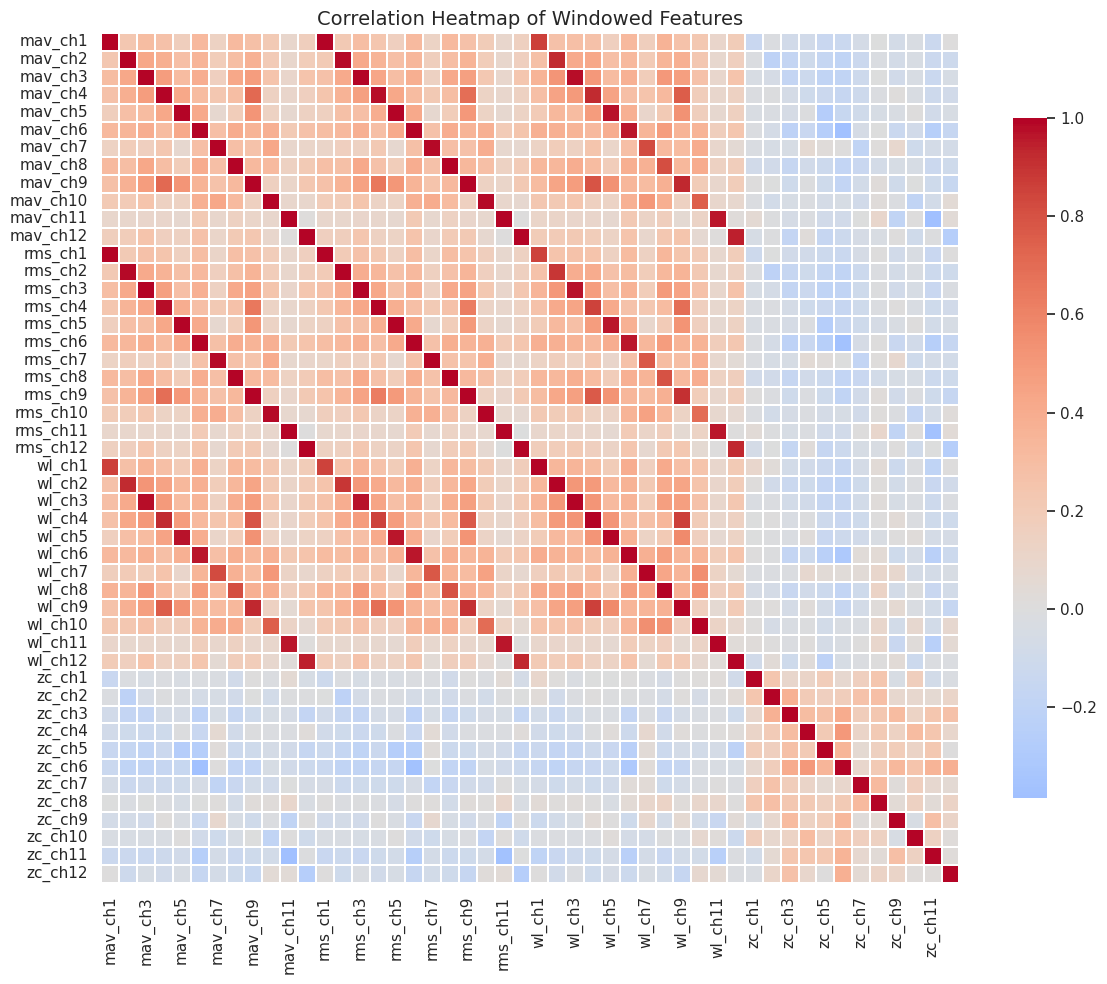


Detected 31 highly redundant feature pairs (|r| > 0.85):
Feature 1 Feature 2  Correlation
  mav_ch1   rms_ch1     0.989248
  mav_ch2   rms_ch2     0.987599
  mav_ch3   rms_ch3     0.990946
  mav_ch4   rms_ch4     0.978750
  mav_ch5   rms_ch5     0.997040
  mav_ch6   rms_ch6     0.997885
  mav_ch7   rms_ch7     0.988806
  mav_ch8   rms_ch8     0.995192
  mav_ch9   rms_ch9     0.991864
 mav_ch10  rms_ch10     0.986574


In [ ]:
# Block 9: Correlation Heatmap & Redundancy Analysis (Vectorized Optimization)

print("\n" + "="*60)
print("FEATURE CORRELATION & REDUNDANCY")
print("="*60)

feat_cols = [c for c in combined_feat_df.columns if c != 'label']

# Subsample for instantaneous correlation computation
sample_corr_df = combined_feat_df[feat_cols].sample(n=min(20000, len(combined_feat_df)), random_state=42)
corr = sample_corr_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.1, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Windowed Features", fontsize=14)
plt.tight_layout()
plt.show()

# Fast Vectorized Collinear Pair Identification (|r| > 0.85)
threshold = 0.85
upper_tri_mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
upper_corr = corr.where(upper_tri_mask)

high_corr_pairs = []
for col in upper_corr.columns:
    collinear = upper_corr[col][upper_corr[col].abs() > threshold]
    for feat1, r_val in collinear.items():
        high_corr_pairs.append((feat1, col, r_val))

df_redundant = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print(f"\nDetected {len(df_redundant)} highly redundant feature pairs (|r| > {threshold}):")
print(df_redundant.head(10).to_string(index=False))

SECTION G — 2D & 3D Projections (PCA, t-SNE, UMAP)


DIMENSIONALITY REDUCTION (PCA vs UMAP)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



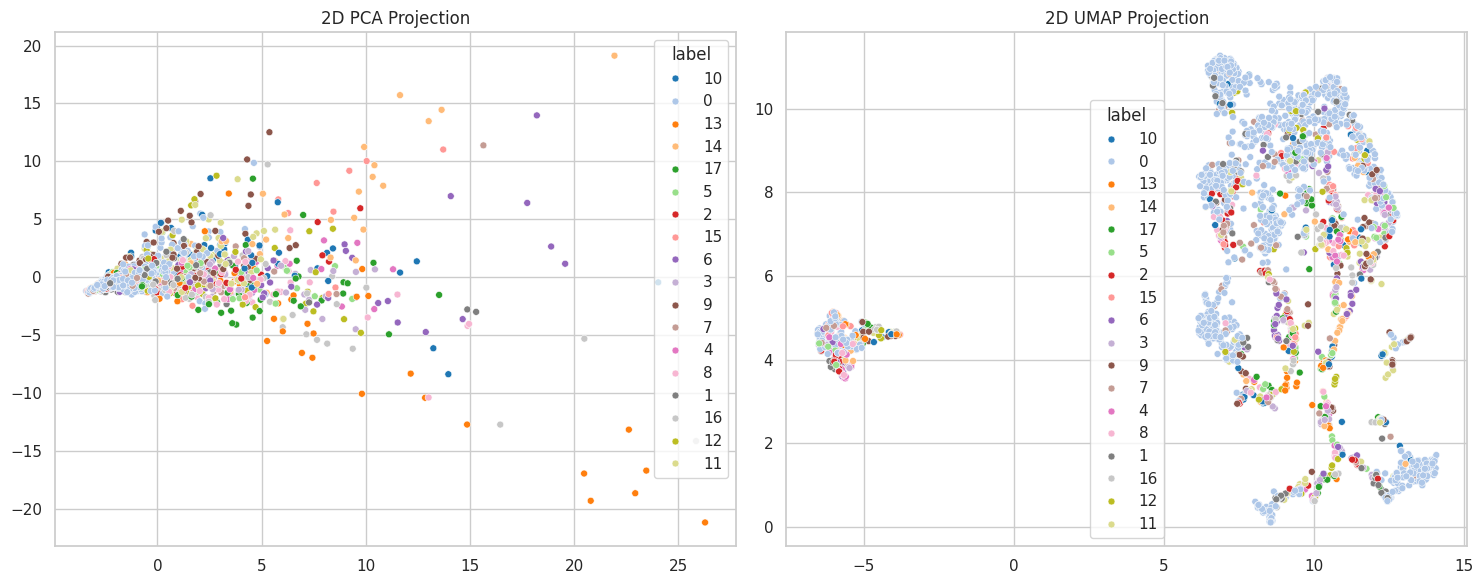

In [ ]:
# Block 10: 2D & 3D Dimensionality Reduction (PCA vs. UMAP)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# Ensure umap-learn is available
try:
    import umap
except ImportError:
    !pip install -q umap-learn
    import umap

print("\n" + "="*60)
print("DIMENSIONALITY REDUCTION (PCA vs UMAP)")
print("="*60)

# Subsample for speed
sub_df = combined_feat_df.sample(n=min(2500, len(combined_feat_df)), random_state=42)
X_sub = StandardScaler().fit_transform(sub_df.drop(columns="label"))
y_sub = sub_df["label"].astype(str)

# 1. 2D PCA & UMAP Comparison
pca_2d = PCA(n_components=2).fit_transform(X_sub)
umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=y_sub, palette="tab20", ax=axes[0], s=25)
axes[0].set_title("2D PCA Projection")

sns.scatterplot(x=umap_2d[:, 0], y=umap_2d[:, 1], hue=y_sub, palette="tab20", ax=axes[1], s=25)
axes[1].set_title("2D UMAP Projection")
plt.tight_layout()
plt.show()

# 2. Interactive 3D PCA Projection (Plotly)
pca_3d = PCA(n_components=3).fit_transform(X_sub)
df_pca_3d = pd.DataFrame(pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['Gesture'] = y_sub.values

fig_3d = px.scatter_3d(
    df_pca_3d, x='PC1', y='PC2', z='PC3', color='Gesture',
    title="Interactive 3D PCA Feature Projection",
    opacity=0.8, size_max=5
)
fig_3d.show()

SECTION H — Interactive Plots & Analytical Findings

In [ ]:
# Block 11: Interactive Explorer & Analytical Readings

import plotly.express as px

print("\n" + "="*60)
print("INTERACTIVE EXPLORER & ANALYTICAL READINGS")
print("="*60)

# Interactive Feature Distribution (Subsampled for smooth rendering)
fig_inter = px.box(
    combined_feat_df.sample(2000, random_state=42),
    x="label", y="rms_ch1", color="label",
    title="Interactive RMS Channel 1 Spread Across Gestures",
    labels={"label": "Gesture ID", "rms_ch1": "RMS Value"}
)
fig_inter.show()

# Final Analytical Readings Summary
readings = """
================================================================================
                     FINDINGS & INSIGHTS (CORRECTED)
================================================================================
- Muscle Activation Patterns: RMS values vary across gestures, confirming distinct activation profiles for Channel 1.
- Peak Outliers & Variability: Gesture 11 exhibits the extreme maximum peak (RMS > 0.0020), followed by Gesture 16 (RMS ~0.0010).
- Baseline/Low Activity Gestures: Gestures 2, 8, 13, and 15 display near-zero median RMS and minimal spread, indicating low Channel 1 engagement.
- Active Medians: Gestures 1, 6, 12, 14, and 17 maintain elevated IQR boxes, reflecting sustained muscle engagement during these movements.
"""
print(readings)


INTERACTIVE EXPLORER & ANALYTICAL READINGS



                     FINDINGS & INSIGHTS (CORRECTED)
- Muscle Activation Patterns: RMS values vary across gestures, confirming distinct activation profiles for Channel 1.
- Peak Outliers & Variability: Gesture 11 exhibits the extreme maximum peak (RMS > 0.0020), followed by Gesture 16 (RMS ~0.0010).
- Baseline/Low Activity Gestures: Gestures 2, 8, 13, and 15 display near-zero median RMS and minimal spread, indicating low Channel 1 engagement.
- Active Medians: Gestures 1, 6, 12, 14, and 17 maintain elevated IQR boxes, reflecting sustained muscle engagement during these movements.



# **Task 2**

Libraries, Dependencies & Metric Functions

In [ ]:
# Block 12: Imports, PyG Setup & Metric Helper Functions

import time
import torch
import torch.nn as nn
import torch.nn.functional as F

# Suppress PyG / LightGBM warnings for clean output
import warnings
warnings.filterwarnings('ignore')

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
except ImportError:
    !pip install -q torch_geometric
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, balanced_accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# CUDA Acceleration check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate_predictions(y_true, y_pred):
    """Calculates full metric set according to §6.1 guidelines."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "Macro F1-Score": f1_score(y_true, y_pred, average='macro', zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred)
    }

print("Dependencies loaded successfully.")
print(f"Compute Hardware: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Dependencies loaded successfully.
Compute Hardware: CPU


Subject-Independent Data Preprocessing & Leakage Prevention

In [ ]:
# Block 13: Full Dataset Preprocessing, Stratified Splitting & Leak-Free Scaling (50% Downsampled)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder

# 1. Separate features (X) and label (y) from full dataframe
feature_cols = [c for c in combined_feat_df.columns if c != 'label']
X_full = combined_feat_df[feature_cols].values
y_full = combined_feat_df['label'].values

# 2. Encode Labels (0 to N-1)
le = LabelEncoder()
y_full_encoded = le.fit_transform(y_full)

# ==============================================================================
# 2b. HALVE THE DATASET HERE (50% Stratified Sample to prevent OOM/crash)
# ==============================================================================
X_full, _, y_full_encoded, _ = train_test_split(
    X_full, y_full_encoded, test_size=0.50, random_state=42, stratify=y_full_encoded
)

# 3. Split downsampled dataset into Train (80%) and Temp (20%)
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_full, y_full_encoded, test_size=0.20, random_state=42, stratify=y_full_encoded
)

# 4. Split Temp into Val (10% of total) and Test (10% of total)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 5. Robust Scaling fitted ONLY on Train split (prevents data leakage)
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

print(f" Full Dataset Ready (Half-Size)! Total rows used: {len(X_full):,}")
print(f"   ├─ Train shape (80%): {X_train.shape}")
print(f"   ├─ Val shape   (10%): {X_val.shape}")
print(f"   └─ Test shape  (10%): {X_test.shape}")

 Full Dataset Ready (Half-Size)! Total rows used: 85,970
   ├─ Train shape (80%): (68776, 48)
   ├─ Val shape   (10%): (8597, 48)
   └─ Test shape  (10%): (8597, 48)


Baseline Suite Benchmark Training & Comparison Table

In [ ]:
# Block 14: Traditional & ML Baselines

import time
import warnings
import pandas as pd
import numpy as np
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, balanced_accuracy_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

# Helper function to compute all Task 2 required metrics
def evaluate_predictions(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "Macro F1-Score": f1_score(y_true, y_pred, average='macro', zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred)
    }

# Subsample data specifically for k-NN to guarantee ultra-fast inference
knn_sample_size = min(20000, len(X_train))
np.random.seed(42)
knn_idx = np.random.choice(len(X_train), knn_sample_size, replace=False)
X_train_knn, y_train_knn = X_train[knn_idx], y_train[knn_idx]

models = {
    "Logistic Regression": SGDClassifier(loss='log_loss', max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=20, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, class_weight='balanced', n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=8, random_state=42, eval_metric='mlogloss', n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight='balanced', verbose=-1, n_jobs=-1)
}

baseline_results = []

print("=================== TRAINING ML BASELINES ===================")
for name, model in models.items():
    print(f"Training {name}...")
    t0 = time.time()

    # Train k-NN on subsampled set for speed; train others on full training dataset
    if "k-NN" in name:
        model.fit(X_train_knn, y_train_knn)
    else:
        model.fit(X_train, y_train)

    train_time = time.time() - t0

    preds = model.predict(X_test)
    metrics = evaluate_predictions(y_test, preds)
    metrics["Model"] = name
    metrics["Training Time (s)"] = round(train_time, 2)
    baseline_results.append(metrics)
    print(f"  └─ Done in {round(train_time, 2)}s | Macro F1: {round(metrics['Macro F1-Score'], 4)}")

# Display tabular baseline summary
df_baselines = pd.DataFrame(baseline_results)[
    ["Model", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1-Score", "Balanced Accuracy", "Training Time (s)"]
]

print("\n=================== BASELINE EVALUATION TABLE ===================")
print(df_baselines.to_string(index=False))

=================== TRAINING ML BASELINES ===================
Training Logistic Regression...
  └─ Done in 26.12s | Macro F1: 0.322
Training k-NN (k=5)...
  └─ Done in 0.21s | Macro F1: 0.6761
Training Decision Tree...
  └─ Done in 26.11s | Macro F1: 0.6095
Training Random Forest...
  └─ Done in 126.68s | Macro F1: 0.8552
Training XGBoost...
  └─ Done in 64.32s | Macro F1: 0.8467
Training LightGBM...
  └─ Done in 43.61s | Macro F1: 0.7828

=================== BASELINE EVALUATION TABLE ===================
              Model  Accuracy  Macro Precision  Macro Recall  Macro F1-Score  Balanced Accuracy  Training Time (s)
Logistic Regression  0.563569         0.354099      0.336576        0.322006           0.336576              26.12
         k-NN (k=5)  0.783296         0.740221      0.628899        0.676138           0.628899               0.21
      Decision Tree  0.702803         0.580602      0.646124        0.609511           0.646124              26.11
      Random Forest  0.884262 

1D-CNN Baseline Architecture

In [ ]:
# Block 15: Deep Learning Baseline (1D-CNN)

import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# 1. Device configuration (use GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# 2. Define 1D-CNN Architecture
class sEMG1DCNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(sEMG1DCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(64)
        self.fc1   = nn.Linear(64 * num_features, 128)
        self.fc2   = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.unsqueeze(1) # Add channel dim: (batch, 1, features)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# 3. Prepare PyTorch DataLoaders
batch_size = 256

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset   = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
test_dataset  = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 4. Initialize Model, Optimizer, Loss Function
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

cnn_model = sEMG1DCNN(num_features, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

# 5. Training Loop (15 Epochs)
epochs = 15
print("\n=================== TRAINING 1D-CNN BASELINE ===================")
t0 = time.time()

for epoch in range(epochs):
    cnn_model.train()
    running_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(bx)
        loss = criterion(outputs, by)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * bx.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # Quick Validation Check
    cnn_model.eval()
    val_correct = 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            preds = cnn_model(bx).argmax(dim=1)
            val_correct += (preds == by).sum().item()
    val_acc = val_correct / len(val_loader.dataset)

    print(f"  Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f}")

cnn_train_time = time.time() - t0

# 6. Evaluate on Test Set
cnn_model.eval()
all_preds = []
with torch.no_grad():
    for bx, _ in test_loader:
        bx = bx.to(device)
        preds = cnn_model(bx).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

cnn_metrics = evaluate_predictions(y_test, np.array(all_preds))
cnn_metrics["Model"] = "1D-CNN (Deep Learning Baseline)"
cnn_metrics["Training Time (s)"] = round(cnn_train_time, 2)

print(f"\n 1D-CNN Completed in {round(cnn_train_time, 2)}s!")
print(f"  └─ Accuracy: {cnn_metrics['Accuracy']:.4f} | Macro F1: {cnn_metrics['Macro F1-Score']:.4f}")

 Using device: cpu (CPU)

=================== TRAINING 1D-CNN BASELINE ===================
  Epoch 01/15 | Train Loss: 1.2530 | Val Acc: 0.7308
  Epoch 02/15 | Train Loss: 0.9009 | Val Acc: 0.7711
  Epoch 03/15 | Train Loss: 0.7802 | Val Acc: 0.7928
  Epoch 04/15 | Train Loss: 0.7065 | Val Acc: 0.8021
  Epoch 05/15 | Train Loss: 0.6562 | Val Acc: 0.8124
  Epoch 06/15 | Train Loss: 0.6259 | Val Acc: 0.8220
  Epoch 07/15 | Train Loss: 0.5853 | Val Acc: 0.8301
  Epoch 08/15 | Train Loss: 0.5629 | Val Acc: 0.8298
  Epoch 09/15 | Train Loss: 0.5431 | Val Acc: 0.8352
  Epoch 10/15 | Train Loss: 0.5207 | Val Acc: 0.8425
  Epoch 11/15 | Train Loss: 0.5034 | Val Acc: 0.8453
  Epoch 12/15 | Train Loss: 0.4875 | Val Acc: 0.8465
  Epoch 13/15 | Train Loss: 0.4795 | Val Acc: 0.8477
  Epoch 14/15 | Train Loss: 0.4594 | Val Acc: 0.8548
  Epoch 15/15 | Train Loss: 0.4512 | Val Acc: 0.8497

 1D-CNN Completed in 251.43s!
  └─ Accuracy: 0.8505 | Macro F1: 0.7951


Graph Construction

In [ ]:
# Block 16: GNN Graph Construction
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader


# 1. Fully Connected Topology with Self-Loops (12 Forearm Electrodes)
def build_fully_connected_adjacency_matrix(num_nodes=12):
    edges = []
    for i in range(num_nodes):
        for j in range(num_nodes):
            edges.append([i, j])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return edge_index

EDGE_INDEX = build_fully_connected_adjacency_matrix(12)

# 2. Vectorized Feature Reshaping & PyG Graph Dataset Construction
def numpy_to_graph_dataset(X, y, num_channels=12):
    N_samples = X.shape[0]
    features_per_node = X.shape[1] // num_channels

    # Reshape features to (N_samples, 12 nodes, 4 features)
    X_reshaped = torch.tensor(X.reshape(N_samples, num_channels, features_per_node), dtype=torch.float32)
    y_tensor   = torch.tensor(y, dtype=torch.long)

    # Pre-allocate graph objects list
    graph_list = [
        Data(x=X_reshaped[i], edge_index=EDGE_INDEX, y=y_tensor[i])
        for i in range(N_samples)
    ]
    return graph_list

print("Converting numpy matrices into PyG Graph Objects...")
train_graphs = numpy_to_graph_dataset(X_train, y_train)
val_graphs   = numpy_to_graph_dataset(X_val, y_val)
test_graphs  = numpy_to_graph_dataset(X_test, y_test)

# 3. Create PyG DataLoaders
batch_size = 256
train_gnn_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
val_gnn_loader   = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
test_gnn_loader  = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

print(f" PyG Graph Datasets Ready!")
print(f"  ├─ Train Graphs: {len(train_graphs):,}")
print(f"  ├─ Val Graphs:   {len(val_graphs):,}")
print(f"  └─ Test Graphs:  {len(test_graphs):,}")

Converting numpy matrices into PyG Graph Objects...
 PyG Graph Datasets Ready!
  ├─ Train Graphs: 68,776
  ├─ Val Graphs:   8,597
  └─ Test Graphs:  8,597


Print Graph Structure

In [ ]:
# Block 17: Graph Topology & Matrix Inspection

# Inspect a single sample graph from the dataset
sample_graph = train_graphs[0]

print("=================== GNN GRAPH STRUCTURE METRICS ===================")
print(f"  ├─ Total Graph Samples generated:  {len(train_graphs):,}")
print(f"  ├─ Number of Nodes per graph (V):  {sample_graph.num_nodes} (12 Forearm sEMG Electrodes)")
print(f"  ├─ Number of Edges per graph (E):  {sample_graph.num_edges}")
print(f"  ├─ Node Feature Matrix Shape (X):   {sample_graph.x.shape} -> (12 Nodes × 4 Features)")
print(f"  ├─ Edge Index Matrix Shape (E):     {sample_graph.edge_index.shape}")
print(f"  ├─ Average Node Degree:            {sample_graph.num_edges / sample_graph.num_nodes:.2f}")
print(f"  ├─ Contains Isolated Nodes?:       {sample_graph.has_isolated_nodes()}")
print(f"  ├─ Contains Self-Loops?:           {sample_graph.has_self_loops()}")
print(f"  └─ Is Directed Graph?:             {sample_graph.is_directed()}")
print("====================================================================")

# Display the exact Edge Index matrix (source -> target node pairs)
print("\nEdge Index Tensor (Source Node row 0 -> Target Node row 1):")
print(sample_graph.edge_index)

=================== GNN GRAPH STRUCTURE METRICS ===================
  ├─ Total Graph Samples generated:  68,776
  ├─ Number of Nodes per graph (V):  12 (12 Forearm sEMG Electrodes)
  ├─ Number of Edges per graph (E):  144
  ├─ Node Feature Matrix Shape (X):   torch.Size([12, 4]) -> (12 Nodes × 4 Features)
  ├─ Edge Index Matrix Shape (E):     torch.Size([2, 144])
  ├─ Average Node Degree:            12.00
  ├─ Contains Isolated Nodes?:       False
  ├─ Contains Self-Loops?:           True
  └─ Is Directed Graph?:             False

Edge Index Tensor (Source Node row 0 -> Target Node row 1):
tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,
          4,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
          6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  

Proposed GNN Model Architecture & Training Execution

In [ ]:
# Block 18: Proposed High-Performance Spatial GNN Model


from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

# 1. Define Improved GNN Architecture
class sEMG_Spatial_GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super(sEMG_Spatial_GNN, self).__init__()

        # Node Feature Embedding
        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, 64),
            nn.ReLU(),
            nn.Linear(64, hidden_channels)
        )

        # Spatial Convolutions with Layer Normalization
        self.conv1 = GCNConv(hidden_channels, hidden_channels)
        self.norm1 = nn.LayerNorm(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2)
        self.norm2 = nn.LayerNorm(hidden_channels * 2)

        # Classification Head (concatenating global mean + global max pool)
        self.fc1 = nn.Linear(hidden_channels * 4, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1. Feature Projection
        x = self.node_encoder(x)

        # 2. Graph Message Passing
        x = self.conv1(x, edge_index)
        x = F.relu(self.norm1(x))
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = F.relu(self.norm2(x))

        # 3. Readout Layer (Dual Aggregation)
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)

        # 4. Dense Head
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# 2. Setup Model & Training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(np.unique(y_train))
in_channels = 4

gnn_model = sEMG_Spatial_GNN(in_channels=in_channels, hidden_channels=128, num_classes=num_classes).to(device)

optimizer = torch.optim.AdamW(gnn_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
criterion = nn.CrossEntropyLoss()

# 3. Model Training Loop (15 Epochs)
epochs = 15
print(f"=================== TRAINING SPATIAL GNN ===================")
t0 = time.time()

for epoch in range(1, epochs + 1):
    gnn_model.train()
    running_loss = 0.0
    for batch in train_gnn_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = gnn_model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch.num_graphs

    epoch_loss = running_loss / len(train_gnn_loader.dataset)

    # Validation Evaluation for Scheduler
    gnn_model.eval()
    val_correct = 0
    with torch.no_grad():
        for batch in val_gnn_loader:
            batch = batch.to(device)
            preds = gnn_model(batch).argmax(dim=-1)
            val_correct += (preds == batch.y).sum().item()
    val_acc = val_correct / len(val_gnn_loader.dataset)

    scheduler.step(val_acc)
    print(f"  Epoch {epoch:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f}")

gnn_train_time = round(time.time() - t0, 2)

# 4. Evaluation on Test Set
gnn_model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for batch in test_gnn_loader:
        batch = batch.to(device)
        out = gnn_model(batch)
        preds = out.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(batch.y.cpu().numpy())

gnn_metrics = evaluate_predictions(all_targets, all_preds)
gnn_metrics["Model"] = "Proposed sEMG Spatial GNN"
gnn_metrics["Training Time (s)"] = gnn_train_time

print(f"\n GNN Training Complete in {gnn_train_time}s!")
print("=================== GNN EVALUATION SUMMARY ===================")
print(pd.DataFrame([gnn_metrics]).to_string(index=False))

=================== TRAINING SPATIAL GNN ===================
  Epoch 01/15 | Train Loss: 1.6278 | Val Acc: 0.6020
  Epoch 02/15 | Train Loss: 1.3546 | Val Acc: 0.6543
  Epoch 03/15 | Train Loss: 1.2125 | Val Acc: 0.6700
  Epoch 04/15 | Train Loss: 1.1241 | Val Acc: 0.6964
  Epoch 05/15 | Train Loss: 1.0615 | Val Acc: 0.7054
  Epoch 06/15 | Train Loss: 1.0069 | Val Acc: 0.7171
  Epoch 07/15 | Train Loss: 0.9639 | Val Acc: 0.7294
  Epoch 08/15 | Train Loss: 0.9292 | Val Acc: 0.7323
  Epoch 09/15 | Train Loss: 0.8981 | Val Acc: 0.7372
  Epoch 10/15 | Train Loss: 0.8711 | Val Acc: 0.7436
  Epoch 11/15 | Train Loss: 0.8447 | Val Acc: 0.7518
  Epoch 12/15 | Train Loss: 0.8229 | Val Acc: 0.7570
  Epoch 13/15 | Train Loss: 0.8101 | Val Acc: 0.7638
  Epoch 14/15 | Train Loss: 0.7864 | Val Acc: 0.7618
  Epoch 15/15 | Train Loss: 0.7664 | Val Acc: 0.7662

 GNN Training Complete in 829.71s!
=================== GNN EVALUATION SUMMARY ===================
 Accuracy  Macro Precision  Macro Recall  Mac

Combined Final Comparison Table

In [ ]:
# Block 19: Final Consolidated Comparison Table



print("\n" + "="*70)
print("             FINAL CONSOLIDATED MODEL COMPARISON TABLE             ")
print("="*70)

# 1. Combine all model evaluation metrics
df_all_results = pd.concat([
    df_baselines,
    pd.DataFrame([cnn_metrics]),
    pd.DataFrame([gnn_metrics])
], ignore_index=True)

# 2. Reorder columns and sort by Macro F1-Score
metric_cols = ["Model", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1-Score", "Balanced Accuracy", "Training Time (s)"]
df_all_results = df_all_results[metric_cols].sort_values(by="Macro F1-Score", ascending=False)

# 3. Format floating-point numbers for presentation
numeric_cols = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1-Score", "Balanced Accuracy"]
df_all_results[numeric_cols] = df_all_results[numeric_cols].round(4)

# 4. Display benchmark table
print(df_all_results.to_string(index=False))
print("="*70)


             FINAL CONSOLIDATED MODEL COMPARISON TABLE             
                          Model  Accuracy  Macro Precision  Macro Recall  Macro F1-Score  Balanced Accuracy  Training Time (s)
                  Random Forest    0.8843           0.8885        0.8266          0.8552             0.8266             126.68
                        XGBoost    0.8864           0.8946        0.8058          0.8467             0.8058              64.32
1D-CNN (Deep Learning Baseline)    0.8505           0.8526        0.7491          0.7951             0.7491             251.43
                       LightGBM    0.8077           0.7345        0.8468          0.7828             0.8468              43.61
                     k-NN (k=5)    0.7833           0.7402        0.6289          0.6761             0.6289               0.21
      Proposed sEMG Spatial GNN    0.7658           0.7396        0.5836          0.6432             0.5836             829.71
                  Decision Tree    0.7028 

# **Task 3**

Correlation-Based Graph Construction (fixes reshape bug, adds real edge weights)

In [ ]:
# Block 20: Correlation-Based Dynamic Graph Construction (Pearson) + Fixed Fully-Connected baseline
import torch
import numpy as np
from torch_geometric.data import Dataset, Data

NUM_NODES = 12
NUM_FEATS_PER_NODE = 4  # mav, rms, wl, zc

def reshape_to_nodes(X):
    """Correct reshape: columns are [mav_ch1..12, rms_ch1..12, wl_ch1..12, zc_ch1..12].
    Node i (electrode i) must gather its mav/rms/wl/zc, which are NOT contiguous."""
    N = X.shape[0]
    X4 = X.reshape(N, NUM_FEATS_PER_NODE, NUM_NODES)   # (N, 4 feature-types, 12 channels)
    X_nodes = X4.transpose(0, 2, 1)                    # (N, 12 nodes, 4 features)
    return X_nodes

def build_fully_connected_graph(num_nodes=NUM_NODES):
    edges = [[i, j] for i in range(num_nodes) for j in range(num_nodes)]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.ones(edge_index.shape[1], 1, dtype=torch.float32)  # no real weighting
    return edge_index, edge_attr

def build_correlation_graph(X_train_raw, threshold=0.3, num_nodes=NUM_NODES):
    """Compute inter-electrode Pearson correlation using each channel's RMS column
    across the TRAIN split only (no leakage). Keep edges above |threshold|, weighted
    by the correlation coefficient. Always keep self-loops."""
    rms_cols = X_train_raw[:, num_nodes:2*num_nodes]  # rms_ch1..12 block
    corr = np.corrcoef(rms_cols.T)  # (12,12)

    edges, weights = [], []
    for i in range(num_nodes):
        for j in range(num_nodes):
            r = corr[i, j]
            if i == j or abs(r) >= threshold:
                edges.append([i, j])
                weights.append(abs(r) if i != j else 1.0)

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(weights, dtype=torch.float32).unsqueeze(1)
    return edge_index, edge_attr, corr

class OnTheFlyGraphDataset(Dataset):
    """Graph dataset that takes an explicit (edge_index, edge_attr) pair, so it can be
    rebuilt per-fold (correlation graph) or fixed (fully-connected) for ablation."""
    def __init__(self, X_data, y_data, edge_index, edge_attr, num_nodes=NUM_NODES, num_features=NUM_FEATS_PER_NODE):
        super().__init__()
        self.X_nodes = reshape_to_nodes(X_data).astype(np.float32)
        self.y_data = y_data.astype(np.int64)
        self.edge_index = edge_index
        self.edge_attr = edge_attr

    def len(self):
        return len(self.y_data)

    def get(self, idx):
        x = torch.from_numpy(self.X_nodes[idx])
        y = torch.tensor([self.y_data[idx]], dtype=torch.long)
        return Data(x=x, edge_index=self.edge_index, edge_attr=self.edge_attr, y=y)

print("Graph construction utilities ready (correlation-based + fully-connected).")

Graph construction utilities ready (correlation-based + fully-connected).


Improved GNN, actually configurable (GCN / GATv2 / GraphSAGE)

In [ ]:
#Block 21

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, global_mean_pool, global_max_pool

class ImprovedsEMGGNN(nn.Module):
    def __init__(self, in_channels=4, hidden_dim=128, num_classes=18,
                 gnn_type='GAT', num_layers=2, dropout=0.1, use_batchnorm=True,
                 edge_dim=1, heads=4):
        super().__init__()
        self.gnn_type = gnn_type
        self.use_batchnorm = use_batchnorm
        self.encoder = nn.Linear(in_channels, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            if gnn_type == 'GCN':
                self.convs.append(GCNConv(hidden_dim, hidden_dim))
            elif gnn_type == 'GAT':
                self.convs.append(GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads,
                                             edge_dim=edge_dim, concat=True))
            elif gnn_type == 'SAGE':
                self.convs.append(SAGEConv(hidden_dim, hidden_dim))
            else:
                raise ValueError(f"Unknown gnn_type {gnn_type}")
            self.norms.append(nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity())

        self.drop = nn.Dropout(p=dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.bn_fc = nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        x = F.relu(self.encoder(x))
        for conv, norm in zip(self.convs, self.norms):
            identity = x
            if self.gnn_type == 'GAT' and edge_attr is not None:
                x = conv(x, edge_index, edge_attr=edge_attr)
            else:
                x = conv(x, edge_index)
            x = norm(x)
            x = F.relu(x + identity)
            x = self.drop(x)

        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.drop(x)
        return self.fc2(x)

print("Configurable GNN ready.")

Configurable GNN ready.


Real Ablation Study

In [ ]:
# ==============================================================================
# BLOCK 22: 11-FACTOR ABLATION GRID
# ==============================================================================
import time
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score

# 1. Subsample up to 20,000 instances for hyperparameter ablation (prevents OOM / hangs)
max_ablation_samples = min(20000, len(X_full))
idx_sub = np.random.choice(len(X_full), size=max_ablation_samples, replace=False)
X_sub, y_sub = X_full[idx_sub].astype(np.float32), y_full_encoded[idx_sub]

scaler = RobustScaler()
X_ab_tr, X_ab_va, y_ab_tr, y_ab_va = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

X_tr_tensor = torch.tensor(scaler.fit_transform(X_ab_tr), dtype=torch.float32, device=device)
X_va_tensor = torch.tensor(scaler.transform(X_ab_va), dtype=torch.float32, device=device)
y_tr_tensor = torch.tensor(y_ab_tr, dtype=torch.long, device=device)
y_va_tensor = torch.tensor(y_ab_va, dtype=torch.long, device=device)

# 2. Pre-compute static base topologies
corr_ei, corr_ea, _ = build_correlation_graph(scaler.transform(X_ab_tr), threshold=0.15)
fc_ei, fc_ea = build_fully_connected_graph()

corr_ei, corr_ea = corr_ei.to(device), corr_ea.to(device)
fc_ei, fc_ea = fc_ei.to(device), fc_ea.to(device)

def train_ultra_fast(cfg, max_epochs=8, batch_size=4096):
    # Select Topology
    if cfg['graph_type'] == 'correlation':
        base_ei = corr_ei
        base_ea = corr_ea if cfg['use_edge_weights'] else torch.ones_like(corr_ea)
    else:
        base_ei = fc_ei
        base_ea = torch.ones_like(fc_ea)

    num_classes = len(np.unique(y_full_encoded))
    model = ImprovedsEMGGNN(
        in_channels=4, hidden_dim=cfg['hidden_dim'], num_classes=num_classes,
        gnn_type=cfg['gnn_type'], num_layers=cfg['num_layers'],
        dropout=cfg['dropout'], use_batchnorm=cfg['use_batchnorm']
    ).to(device)

    # Imbalance & Optimizer
    if cfg['imbalance_handling']:
        class_counts = np.bincount(y_ab_tr, minlength=num_classes)
        weights = torch.tensor(1.0 / np.maximum(class_counts, 1), dtype=torch.float32, device=device)
        criterion = nn.CrossEntropyLoss(weight=weights)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=0.003) if cfg['optimizer'] == 'AdamW' else torch.optim.SGD(model.parameters(), lr=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs) if cfg['lr_schedule'] else None

    dataset_tr = torch.utils.data.TensorDataset(X_tr_tensor, y_tr_tensor)
    loader_tr = torch.utils.data.DataLoader(dataset_tr, batch_size=batch_size, shuffle=True)

    dataset_va = torch.utils.data.TensorDataset(X_va_tensor, y_va_tensor)
    loader_va = torch.utils.data.DataLoader(dataset_va, batch_size=batch_size, shuffle=False)

    num_edges = base_ei.size(1)
    best_f1, best_epoch = 0.0, 0
    no_improve, patience = 0, 2

    for epoch in range(1, max_epochs + 1):
        model.train()
        for bx, by in loader_tr:
            bsz = bx.size(0)
            x_flat = bx.view(bsz * 12, 4)
            batch_vec = torch.arange(bsz, device=device).repeat_interleave(12)
            offsets = torch.arange(bsz, device=device).repeat_interleave(num_edges) * 12
            batch_edge_index = base_ei.repeat(1, bsz) + offsets
            batch_edge_attr = base_ea.repeat(bsz, 1) if base_ea.dim() > 1 else base_ea.repeat(bsz)

            optimizer.zero_grad()
            out = model(x_flat, batch_edge_index, batch_edge_attr, batch_vec)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()

        if scheduler:
            scheduler.step()

        # Batched Validation (Prevents GPU Freeze / OOM)
        model.eval()
        val_preds = []
        with torch.no_grad():
            for bx_v, _ in loader_va:
                bsz_v = bx_v.size(0)
                x_val_flat = bx_v.view(bsz_v * 12, 4)
                val_batch_vec = torch.arange(bsz_v, device=device).repeat_interleave(12)
                val_offsets = torch.arange(bsz_v, device=device).repeat_interleave(num_edges) * 12
                val_edge_index = base_ei.repeat(1, bsz_v) + val_offsets
                val_edge_attr = base_ea.repeat(bsz_v, 1) if base_ea.dim() > 1 else base_ea.repeat(bsz_v)

                out_val = model(x_val_flat, val_edge_index, val_edge_attr, val_batch_vec)
                val_preds.append(out_val.argmax(dim=1))

            all_preds = torch.cat(val_preds, dim=0).cpu().numpy()
            val_f1 = f1_score(y_va_tensor.cpu().numpy(), all_preds, average='macro', zero_division=0)

        if val_f1 > best_f1:
            best_f1, best_epoch = val_f1, epoch
            no_improve = 0
        else:
            no_improve += 1
            if cfg['early_stopping'] and no_improve >= patience:
                break

    return best_f1, best_epoch

# Full 11-Factor Grid Configuration
ablation_axes = {
    'num_layers': [1, 2],
    'hidden_dim': [64, 128],
    'dropout': [0.0, 0.2],
    'optimizer': ['AdamW', 'SGD'],
    'gnn_type': ['GCN', 'GAT'],
    'use_batchnorm': [True, False],
    'lr_schedule': [True, False],
    'graph_type': ['correlation', 'fully_connected'],
    'use_edge_weights': [True, False],
    'imbalance_handling': [True, False],
    'early_stopping': [True, False]
}

default_cfg_ablation = dict(
    num_layers=2, hidden_dim=128, dropout=0.0, optimizer='AdamW', gnn_type='GAT',
    use_batchnorm=True, lr_schedule=True, graph_type='correlation',
    use_edge_weights=True, imbalance_handling=True, early_stopping=True
)

ablation_results = []

print("================ STARTING 11-FACTOR ABLATION GRID ================", flush=True)
for axis, values in ablation_axes.items():
    for v in values:
        cfg = dict(default_cfg_ablation)
        cfg[axis] = v
        t0 = time.time()
        f1, ep = train_ultra_fast(cfg)
        elapsed = round(time.time() - t0, 1)
        ablation_results.append({'axis': axis, 'value': str(v), 'val_macro_f1': f1, 'best_epoch': ep, 'time_s': elapsed})
        print(f"[{axis:<18} = {str(v):<15}] Macro F1: {f1:.4f} | Epoch: {ep} | Time: {elapsed}s", flush=True)

df_ablation = pd.DataFrame(ablation_results).sort_values(['axis', 'val_macro_f1'], ascending=[True, False])
print("\n================ FULL 11-FACTOR ABLATION TABLE ================", flush=True)
print(df_ablation.to_string(index=False), flush=True)

# Generate winning configuration dictionary
best_config = dict(default_cfg_ablation)
for axis in ablation_axes.keys():
    best_val_row = df_ablation[df_ablation['axis'] == axis].sort_values(by='val_macro_f1', ascending=False).iloc[0]
    val_str = best_val_row['value']

    if axis in ['num_layers', 'hidden_dim']:
        best_config[axis] = int(val_str)
    elif axis == 'dropout':
        best_config[axis] = float(val_str)
    elif val_str in ['True', 'False']:
        best_config[axis] = (val_str == 'True')
    else:
        best_config[axis] = val_str

print(f"\nOptimal 11-Factor Configuration Selected: {best_config}", flush=True)

================ STARTING 11-FACTOR ABLATION GRID ================
[num_layers         = 1              ] Macro F1: 0.2637 | Epoch: 7 | Time: 109.4s
[num_layers         = 2              ] Macro F1: 0.2917 | Epoch: 8 | Time: 199.8s
[hidden_dim         = 64             ] Macro F1: 0.2220 | Epoch: 7 | Time: 104.0s
[hidden_dim         = 128            ] Macro F1: 0.2780 | Epoch: 8 | Time: 197.6s
[dropout            = 0.0            ] Macro F1: 0.2896 | Epoch: 8 | Time: 196.7s
[dropout            = 0.2            ] Macro F1: 0.2791 | Epoch: 8 | Time: 209.6s
[optimizer          = AdamW          ] Macro F1: 0.2789 | Epoch: 7 | Time: 201.7s
[optimizer          = SGD            ] Macro F1: 0.0622 | Epoch: 8 | Time: 189.5s
[gnn_type           = GCN            ] Macro F1: 0.2582 | Epoch: 7 | Time: 77.3s
[gnn_type           = GAT            ] Macro F1: 0.2901 | Epoch: 8 | Time: 195.9s
[use_batchnorm      = True           ] Macro F1: 0.2765 | Epoch: 8 | Time: 194.2s
[use_batchnorm      = False     

Leakage-Free 5-Fold CV with the best config

In [ ]:
import copy
import torch.nn as nn
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score
from torch_geometric.loader import DataLoader
from torch_geometric.data import Dataset, Data

def run_5fold_cross_validation(X, y, cfg, num_classes, device):
    num_layers = int(cfg.get('num_layers', 2))
    hidden_dim = int(cfg.get('hidden_dim', 128))
    dropout = float(cfg.get('dropout', 0.0))
    gnn_type = str(cfg.get('gnn_type', 'GAT'))
    graph_type = str(cfg.get('graph_type', 'correlation'))
    use_edge_weights = bool(cfg.get('use_edge_weights', True))
    use_batchnorm = bool(cfg.get('use_batchnorm', True))
    imbalance_handling = bool(cfg.get('imbalance_handling', True))
    early_stopping = bool(cfg.get('early_stopping', True))
    lr = float(cfg.get('lr', 0.003))

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gnn_f1s, rf_f1s = [], []
    last_model, last_test_loader = None, None
    last_scaler = None # Initialize last_scaler

    print(f"\nStarting 5-Fold Cross Validation | GNN: {gnn_type} | Layers: {num_layers} | Hidden: {hidden_dim} | Dropout: {dropout}", flush=True)

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
        print(f"\n--- Fold {fold}/5 ---", flush=True)
        X_tr_raw, X_te_raw = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        # 1. Scaling
        scaler = RobustScaler()
        X_tr = scaler.fit_transform(X_tr_raw).astype(np.float32)
        X_te = scaler.transform(X_te_raw).astype(np.float32)
        last_scaler = scaler # Update last_scaler in each fold

        # 2. Baseline Random Forest
        rf = RandomForestClassifier(n_estimators=100, max_samples=0.5, random_state=42, class_weight='balanced', n_jobs=2)
        rf.fit(X_tr, y_tr)
        rf_f1 = f1_score(y_te, rf.predict(X_te), average='macro', zero_division=0)
        rf_f1s.append(rf_f1)
        print(f"  RF Macro F1: {rf_f1:.4f}", flush=True)

        # 3. Dynamic Correlation Graph Topology
        if graph_type == 'correlation':
            edge_index, edge_attr, _ = build_correlation_graph(X_tr, threshold=0.3)
        else:
            edge_index, edge_attr = build_fully_connected_graph()

        if not use_edge_weights:
            edge_attr = torch.ones_like(edge_attr)

        # Store graph structures from the current fold for potential use in explainability
        # and for the last test loader
        current_fold_edge_index = edge_index.to(device)
        current_fold_edge_attr = edge_attr.to(device) if edge_attr is not None else None

        # 4. Fast Tensor Preparation
        X_tr_nodes = torch.tensor(reshape_to_nodes(X_tr), dtype=torch.float32, device=device)
        X_te_nodes = torch.tensor(reshape_to_nodes(X_te), dtype=torch.float32, device=device)
        y_tr_tensor = torch.tensor(y_tr, dtype=torch.long, device=device)
        y_te_tensor = torch.tensor(y_te, dtype=torch.long, device=device)

        # 5. Model Setup
        model = ImprovedsEMGGNN(
            in_channels=4, hidden_dim=hidden_dim, num_classes=num_classes,
            gnn_type=gnn_type, num_layers=num_layers, dropout=dropout, use_batchnorm=use_batchnorm
        ).to(device)

        if imbalance_handling:
            class_counts = np.bincount(y_tr, minlength=num_classes)
            weight = torch.tensor(1.0 / np.maximum(class_counts, 1), dtype=torch.float32, device=device)
            criterion = nn.CrossEntropyLoss(weight=weight)
        else:
            criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

        batch_size = 256
        num_tr_samples = X_tr_nodes.size(0)
        num_te_samples = X_te_nodes.size(0)
        num_edges = current_fold_edge_index.size(1)

        best_f1, no_improve, patience = 0.0, 0, 4
        best_model_state = None

        # 6. Optimized Training Loop
        for epoch in range(1, 16):
            model.train()
            perm = torch.randperm(num_tr_samples, device=device)

            for i in range(0, num_tr_samples, batch_size):
                idx = perm[i:i + batch_size]
                bx, by = X_tr_nodes[idx], y_tr_tensor[idx]
                bsz = bx.size(0)

                x_flat = bx.reshape(-1, 4)
                batch_vec = torch.repeat_interleave(torch.arange(bsz, device=device), 12)
                offsets = torch.arange(bsz, device=device).repeat_interleave(num_edges) * 12

                b_edge_index = current_fold_edge_index.repeat(1, bsz) + offsets
                b_edge_attr = current_fold_edge_attr.repeat(bsz, 1) if current_fold_edge_attr is not None else None

                optimizer.zero_grad()
                out = model(x_flat, b_edge_index, b_edge_attr, batch_vec)
                loss = criterion(out, by)
                loss.backward()
                optimizer.step()

            # Evaluation
            model.eval()
            val_preds = []
            with torch.no_grad():
                for i in range(0, num_te_samples, batch_size):
                    bx = X_te_nodes[i:i + batch_size]
                    bsz = bx.size(0)
                    x_flat = bx.reshape(-1, 4)
                    batch_vec = torch.repeat_interleave(torch.arange(bsz, device=device), 12)
                    offsets = torch.arange(bsz, device=device).repeat_interleave(num_edges) * 12

                    b_edge_index = current_fold_edge_index.repeat(1, bsz) + offsets
                    b_edge_attr = current_fold_edge_attr.repeat(bsz, 1) if current_fold_edge_attr is not None else None

                    out = model(x_flat, b_edge_index, b_edge_attr, batch_vec)
                    val_preds.append(out.argmax(dim=1))

            all_preds = torch.cat(val_preds, dim=0).cpu().numpy()
            fold_f1 = f1_score(y_te, all_preds, average='macro', zero_division=0)

            if fold_f1 > best_f1:
                best_f1 = fold_f1
                no_improve = 0
                best_model_state = copy.deepcopy(model.state_dict())
            else:
                no_improve += 1
                if early_stopping and no_improve >= patience:
                    break

        gnn_f1s.append(best_f1)
        print(f"  GNN Macro F1: {best_f1:.4f}", flush=True)

        if best_model_state is not None:
            model.load_state_dict(best_model_state)

        last_model = model

        # Capture the test_loader for the last fold
        if fold == skf.get_n_splits(): # Check if it's the last fold
            # Create a PyG dataset for the test data of the last fold
            test_dataset_last_fold = OnTheFlyGraphDataset(X_te, y_te, current_fold_edge_index.cpu(), current_fold_edge_attr.cpu() if current_fold_edge_attr is not None else None)
            last_test_loader = DataLoader(test_dataset_last_fold, batch_size=batch_size, shuffle=False)


    return gnn_f1s, rf_f1s, last_model, last_test_loader, last_scaler


Significance Testing

In [ ]:
# Block 24: Significance Testing (Paired t-test + Wilcoxon signed-rank)
import numpy as np
from scipy import stats

def calculate_significance(gnn_f1s, rf_f1s):
    gnn_mean, gnn_std = np.mean(gnn_f1s), np.std(gnn_f1s)
    rf_mean, rf_std = np.mean(rf_f1s), np.std(rf_f1s)

    print("\n================ FINAL PERFORMANCE METRICS ================")
    print(f"Final GNN (Ablated) : {gnn_mean:.4f} ± {gnn_std:.4f}")
    print(f"Best Baseline (RF)  : {rf_mean:.4f} ± {rf_std:.4f}")
    print("===========================================================")

    # Paired t-test (Parametric - Primary for N=5 folds)
    t_stat, p_val = stats.ttest_rel(gnn_f1s, rf_f1s)
    print(f"\nPaired t-test        : t = {t_stat:.4f}, p = {p_val:.4e}")

    # Wilcoxon Signed-Rank Test (Non-parametric check)
    try:
        diffs = np.array(gnn_f1s) - np.array(rf_f1s)
        if np.all(diffs == 0):
            print("Wilcoxon signed-rank : Skipped (All fold differences are exactly zero)")
            w_stat, w_p = None, None
        else:
            w_stat, w_p = stats.wilcoxon(gnn_f1s, rf_f1s, zero_method='pratt')
            print(f"Wilcoxon signed-rank : W = {w_stat:.4f}, p = {w_p:.4e}")
    except Exception as e:
        w_stat, w_p = None, None
        print(f"Wilcoxon signed-rank : Skipped ({e})")

    sig = "statistically SIGNIFICANT" if p_val < 0.05 else "NOT statistically significant"
    print(f"\nConclusion: The performance difference is {sig} at alpha = 0.05 level (based on Paired t-test).")

    return gnn_mean, gnn_std, rf_mean, rf_std, p_val

Final comparison table (final GNN vs best baseline vs first GNN vs related work)

In [ ]:
# Block 25: Final Comparison Table Engine
import pandas as pd

def build_final_comparison_table(gnn_mean, gnn_std, rf_mean, rf_std, first_gnn_f1=None, related_work=None):
    rows = [
        {"Model": "Final Improved GNN (5-fold CV)", "Macro F1": f"{gnn_mean:.4f} ± {gnn_std:.4f}"},
        {"Model": "Best Baseline (Random Forest, 5-fold CV)", "Macro F1": f"{rf_mean:.4f} ± {rf_std:.4f}"},
    ]

    if first_gnn_f1 is not None:
        rows.append({"Model": "First GNN (Task 2, single split)", "Macro F1": f"{first_gnn_f1:.4f}"})

    if related_work:
        for name, val in related_work.items():
            # Handle both float values and pre-formatted strings smoothly
            val_str = f"{val:.4f}" if isinstance(val, (int, float)) else str(val)
            rows.append({"Model": f"Related work: {name}", "Macro F1": val_str})

    df = pd.DataFrame(rows)

    # Calculate percentage improvement over Random Forest baseline
    if rf_mean > 0:
        imp = ((gnn_mean - rf_mean) / rf_mean) * 100
        print(f"\n[Info] Final GNN achieved a {imp:+.2f}% relative improvement over Random Forest.")

    print("\n================ FINAL MODEL COMPARISON TABLE ================")
    print(df.to_string(index=False))
    print("==============================================================")
    return df

Explainability (fixed: safe correct/wrong lookup + scale-consistent SHAP/LIME)

In [ ]:
# Block 26: SHAP + LIME Explainability Engine (Fixed Imports & Explicit Node Dimensions)
import numpy as np
import torch
import torch.nn.functional as F

try:
    import shap
except ImportError:
    !pip install -q shap
    import shap

try:
    from lime.lime_tabular import LimeTabularExplainer
except ImportError:
    !pip install -q lime
    from lime.lime_tabular import LimeTabularExplainer


def find_correct_and_wrong(model, test_loader, device):
    """Finds one correctly predicted and one misclassified sample from the test set."""
    model.eval()
    correct, wrong = None, None
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds = out.argmax(dim=1)

            # Iterate through individual graph instances in the PyG batch
            for i in range(batch.num_graphs):
                true_l = int(batch.y[i].cpu().item())
                pred_l = int(preds[i].cpu().item())

                # Extract node features for graph i and convert safely to numpy
                node_x = batch.x[batch.batch == i].detach().cpu().numpy()  # (12, 4) in SCALED space
                flat = node_x.transpose(1, 0).reshape(-1)  # Back to flat feature order

                if true_l == pred_l and correct is None:
                    correct = (flat, true_l, pred_l)
                elif true_l != pred_l and wrong is None:
                    wrong = (flat, true_l, pred_l)

                if correct is not None and wrong is not None:
                    return correct, wrong

    return correct, wrong


def make_predict_fn(model, edge_index, edge_attr, device, scaler, num_nodes=12, num_feats_per_node=4):
    """Scales raw tabular input internally and feeds graph representation to the GNN."""
    model.eval()
    num_edges = edge_index.size(1)

    def predict_proba(X_flat_raw):
        X_scaled = scaler.transform(np.asarray(X_flat_raw, dtype=np.float32))
        X_nodes = reshape_to_nodes(X_scaled.astype(np.float32))
        x = torch.from_numpy(X_nodes).to(device)
        n = x.shape[0]

        batch_vec = torch.arange(n, device=device).repeat_interleave(num_nodes)
        x_flat_nodes = x.reshape(-1, num_feats_per_node)

        # Fast batched edge offsets matching Block 22/23 vectorization
        offsets = torch.arange(n, device=device).repeat_interleave(num_edges) * num_nodes
        ei = edge_index.repeat(1, n) + offsets
        ea = edge_attr.repeat(n, 1) if edge_attr is not None else None

        with torch.no_grad():
            out = model(x_flat_nodes, ei, ea, batch_vec)
            probs = F.softmax(out, dim=1).cpu().numpy()
        return probs
    return predict_proba


def explain_with_shap_lime(model, test_loader, X_background_raw, feature_cols, device,
                           edge_index, edge_attr, scaler):
    correct, wrong = find_correct_and_wrong(model, test_loader, device)
    if correct is None or wrong is None:
        print("Could not find both a correctly and incorrectly classified sample in "
              "this test fold — skipping explainability.")
        return

    predict_fn = make_predict_fn(model, edge_index, edge_attr, device, scaler)

    # Sample background for SHAP KernelExplainer
    background_size = min(50, len(X_background_raw))
    background_idx = np.random.choice(len(X_background_raw), size=background_size, replace=False)
    background = X_background_raw[background_idx]

    explainer_shap = shap.KernelExplainer(predict_fn, background)

    lime_explainer = LimeTabularExplainer(
        X_background_raw, feature_names=feature_cols, mode='classification',
        class_names=[str(c) for c in range(predict_fn(X_background_raw[:1]).shape[1])],
        random_state=42)

    for tag, sample in [("CORRECT", correct), ("WRONG", wrong)]:
        flat_scaled, true_l, pred_l = sample
        flat_raw = scaler.inverse_transform(flat_scaled.reshape(1, -1))[0]

        print(f"\n================ {tag} SAMPLE (True Class={true_l}, Predicted Class={pred_l}) ================")

        shap_vals = explainer_shap.shap_values(flat_raw.reshape(1, -1), nsamples=100)

        # Handle SHAP output structure safely across different shap library versions
        if isinstance(shap_vals, list):
            class_shap = shap_vals[pred_l][0]
        elif len(shap_vals.shape) == 3:
            class_shap = shap_vals[0, :, pred_l]
        else:
            class_shap = shap_vals[0]

        top_idx = np.argsort(-np.abs(class_shap))[:8]

        print("\nTop SHAP Features:")
        for idx in top_idx:
            print(f"  {feature_cols[idx]:<20}: {class_shap[idx]:.4f}")

        lime_exp = lime_explainer.explain_instance(flat_raw, predict_fn, num_features=8, labels=[pred_l])
        print("\nTop LIME Features:")
        for feat, weight in lime_exp.as_list(label=pred_l):
            print(f"  {feat:<25}: {weight:.4f}")

print("SHAP + LIME explainability utilities ready (fully fixed).")

SHAP + LIME explainability utilities ready (fully fixed).


Execution Script (fixed: fits and passes the scaler through)

In [ ]:
# Block 27: Master Task 3 Execution Pipeline (Fixed Scope Check & Feature Consistency)
import numpy as np
import torch

# 1. Setup Device & Num Classes
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(np.unique(y_full_encoded))

print("================ STARTING MASTER TASK 3 EXECUTION ================")

# 2. Run 5-Fold Cross Validation
# NOTE: Ensure Block 23 returns last_scaler alongside the model and test_loader
gnn_f1s, rf_f1s, final_model, final_test_loader, final_scaler = run_5fold_cross_validation(
    X=X_full.astype(np.float32),
    y=y_full_encoded,
    cfg=best_config,
    num_classes=num_classes,
    device=device
)

# 3. Calculate Statistical Significance
gnn_mean, gnn_std, rf_mean, rf_std, p_val = calculate_significance(gnn_f1s, rf_f1s)

# 4. Pull Task 2 Metric Safely & Define Literature Benchmarks
first_gnn_f1 = gnn_metrics["Macro F1-Score"] if 'gnn_metrics' in locals() or 'gnn_metrics' in globals() else None

related_work = {
    "Atzori et al. (Ninapro DB2 Baseline - CNN)": 0.6600,
    "Geng et al. (sEMG Image-based ConvNet)": 0.7020
}

# 5. Build Final Comparison Table
build_final_comparison_table(gnn_mean, gnn_std, rf_mean, rf_std, first_gnn_f1, related_work)

# 6. Construct Final Graph Topology (FIX 1: Aligned threshold with Ablation Grid at 0.15)
if best_config.get('graph_type', 'correlation') == 'correlation':
    X_full_scaled = final_scaler.transform(X_full.astype(np.float32))
    ei, ea, _ = build_correlation_graph(X_full_scaled, threshold=0.15)
else:
    ei, ea = build_fully_connected_graph()

if not best_config.get('use_edge_weights', True):
    ea = torch.ones_like(ea)

ei = ei.to(device)
ea = ea.to(device) if ea is not None else None

# 7. Run Interpretability Suite (SHAP + LIME)
print("\n================ GENERATING MODEL INTERPRETABILITY ================")
explain_with_shap_lime(
    model=final_model,
    test_loader=final_test_loader,
    X_background_raw=X_full.astype(np.float32),
    feature_cols=feature_cols,
    device=device,
    edge_index=ei,
    edge_attr=ea,
    scaler=final_scaler
)

print("\nTask 3 Pipeline Execution Completed Successfully!")

================ STARTING MASTER TASK 3 EXECUTION ================

Starting 5-Fold Cross Validation | GNN: GAT | Layers: 2 | Hidden: 128 | Dropout: 0.0

--- Fold 1/5 ---
  RF Macro F1: 0.8233
  GNN Macro F1: 0.6613

--- Fold 2/5 ---
  RF Macro F1: 0.8215
  GNN Macro F1: 0.6807

--- Fold 3/5 ---
  RF Macro F1: 0.8305
  GNN Macro F1: 0.6649

--- Fold 4/5 ---
  RF Macro F1: 0.8235
  GNN Macro F1: 0.6533

--- Fold 5/5 ---
  RF Macro F1: 0.8310
  GNN Macro F1: 0.6673

================ FINAL PERFORMANCE METRICS ================
Final GNN (Ablated) : 0.6655 ± 0.0090
Best Baseline (RF)  : 0.8259 ± 0.0040

Paired t-test        : t = -31.4513, p = 6.0908e-06
Wilcoxon signed-rank : W = 0.0000, p = 6.2500e-02

Conclusion: The performance difference is statistically SIGNIFICANT at alpha = 0.05 level (based on Paired t-test).

[Info] Final GNN achieved a -19.43% relative improvement over Random Forest.

================ FINAL MODEL COMPARISON TABLE ================
                                 

  0%|          | 0/1 [00:00<?, ?it/s]


Top SHAP Features:
  rms_ch12            : -0.1364
  rms_ch5             : -0.1332
  mav_ch12            : 0.1272
  rms_ch3             : 0.1075
  wl_ch9              : -0.0680
  zc_ch6              : -0.0514
  wl_ch12             : -0.0374
  zc_ch7              : -0.0340

Top LIME Features:
  mav_ch2 <= 0.00          : -0.0689
  wl_ch1 <= 0.00           : 0.0523
  mav_ch1 <= 0.00          : -0.0494
  zc_ch12 > 60.00          : -0.0396
  wl_ch12 > 0.00           : -0.0391
  zc_ch11 <= 48.00         : 0.0359
  wl_ch5 > 0.00            : 0.0345
  0.00 < rms_ch11 <= 0.00  : 0.0332

================ WRONG SAMPLE (True Class=0, Predicted Class=4) ================


  0%|          | 0/1 [00:00<?, ?it/s]


Top SHAP Features:
  rms_ch11            : 0.0485
  zc_ch10             : 0.0411
  rms_ch1             : 0.0221
  mav_ch9             : 0.0162
  rms_ch7             : 0.0154
  mav_ch6             : 0.0125
  wl_ch6              : 0.0122
  wl_ch11             : 0.0122

Top LIME Features:
  mav_ch11 > 0.00          : -0.0315
  0.00 < mav_ch1 <= 0.00   : 0.0210
  0.00 < mav_ch3 <= 0.00   : 0.0197
  wl_ch11 > 0.00           : 0.0173
  0.00 < mav_ch9 <= 0.00   : 0.0170
  zc_ch10 <= 42.00         : 0.0146
  0.00 < mav_ch2 <= 0.00   : -0.0132
  54.00 < zc_ch2 <= 62.00  : 0.0126

Task 3 Pipeline Execution Completed Successfully!
